# Capítulo 24 — Naive Bayes

En el capítulo anterior estudiamos Support Vector Machines, un enfoque que interpreta la clasificación mediante fronteras y márgenes. Ahora cambiaremos de perspectiva: **Naive Bayes** clasifica combinando evidencias probabilísticas.

Usaremos una colección didáctica de mensajes en español. Cada texto está etiquetado como spam o legítimo. El objetivo no es construir un filtro listo para usar, sino observar con claridad cómo las palabras se transforman en variables, cómo el modelo aprende frecuencias por clase y cómo esas frecuencias influyen en una predicción.

El conjunto fue escrito especialmente para este cuaderno. Es pequeño y simplifica mucho el lenguaje real; por eso sus resultados no deben interpretarse como el desempeño de un sistema de correo real.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- explicar la clasificación de Naive Bayes como combinación de evidencias;
- reconocer el supuesto de independencia condicional;
- transformar textos en conteos con `CountVectorizer`;
- interpretar probabilidades previas y probabilidades de palabras por clase;
- reconstruir una predicción a partir de los valores aprendidos;
- explicar por qué el suavizado evita probabilidades nulas;
- distinguir `MultinomialNB`, `BernoulliNB` y `GaussianNB`;
- evaluar el vectorizador y el modelo juntos mediante un pipeline;
- comparar Naive Bayes con referencias usando los mismos folds;
- reconocer ventajas y limitaciones del enfoque.


## 1. Importar las herramientas

Usaremos Pandas y NumPy para organizar los resultados, Matplotlib para visualizarlos y `scikit-learn` para vectorizar textos, construir pipelines y evaluar clasificadores.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.pipeline import Pipeline

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.max_columns", None)


## 2. Preparar una colección didáctica de mensajes

La clase positiva será `spam = 1`. Incluimos casos claros y algunos mensajes ambiguos. Por ejemplo, palabras como “gratis”, “oferta”, “factura” o “enlace” pueden aparecer tanto en mensajes peligrosos como en comunicaciones legítimas.

Esa superposición evita convertir el ejercicio en una regla trivial basada en una sola palabra.


In [2]:
mensajes_spam = [
    "Oferta exclusiva: ganaste un premio, hacé clic para reclamarlo",
    "Crédito inmediato sin requisitos, completá tus datos en este enlace",
    "Último aviso: tu cuenta será cerrada, verificá ahora tu contraseña",
    "Ganaste un teléfono gratis, ingresá al enlace para recibirlo",
    "Promoción urgente: descuento total solo por hoy",
    "Tu paquete está retenido, pagá la tasa desde este enlace",
    "Felicitaciones, fuiste seleccionado para un premio en efectivo",
    "Oferta de inversión: duplicá tu dinero con bitcoin esta semana",
    "Banco: detectamos un problema, confirmá tus datos de acceso",
    "Cupón gratis disponible, hacé clic antes de que venza",
    "Trabajo desde casa con ganancias rápidas, registrate ahora",
    "Préstamo aprobado sin consulta, respondé con tus datos personales",
    "Factura pendiente: abrí el archivo y confirmá el pago urgente",
    "Tu correo superó el límite, iniciá sesión desde este enlace",
    "Promoción especial para clientes: reclamá tu regalo ahora",
    "Ganaste entradas gratis, verificá tu identidad para recibirlas",
    "Alerta de seguridad: enviá tu clave para evitar el bloqueo",
    "Oferta limitada de criptomonedas con retorno garantizado",
    "Premio disponible: pagá un pequeño cargo para liberarlo",
    "Actualizá tu cuenta bancaria haciendo clic en el enlace adjunto",
    "Sorteo internacional: sos el ganador, respondé con tu documento",
    "Descuento exclusivo: comprá ahora y recibí otro producto gratis",
    "Aviso de cobro: descargá la factura desde este enlace desconocido",
    "Tu suscripción vence hoy, confirmá la tarjeta con urgencia",
    "Reunión financiera privada: inversión segura y ganancia inmediata",
    "Mensaje del soporte: necesitamos tu contraseña para ayudarte",
    "Acceso bloqueado: validá la cuenta antes de las próximas dos horas",
    "Premio bitcoin asignado, activalo con un pago mínimo",
    "Oferta laboral sin entrevista, enviá foto del documento",
    "Recibiste una transferencia, ingresá al enlace para aceptarla",
    "Promoción gratis para los primeros usuarios que completen sus datos",
    "Tu factura tiene un reintegro, confirmá tu cuenta bancaria",
]

mensajes_legitimos = [
    "La reunión de equipo se trasladó al martes a las diez",
    "Adjunto la factura del servicio correspondiente a este mes",
    "La biblioteca ofrece un taller gratuito para estudiantes",
    "Recordatorio: mañana vence la entrega del informe",
    "¿Podés revisar el documento antes de nuestra reunión?",
    "El museo tendrá entrada gratis durante el fin de semana",
    "Tu pedido fue enviado y llegará el jueves por la tarde",
    "La profesora compartió el enlace al material de la clase",
    "Confirmamos tu turno médico para el lunes a las nueve",
    "La cooperadora organiza un sorteo para financiar la biblioteca",
    "Recibimos tu pago, podés descargar la factura desde el portal",
    "La oferta académica del próximo semestre ya está publicada",
    "Te envío las fotos de la reunión familiar del domingo",
    "El banco informa el nuevo horario de atención de la sucursal",
    "La entrada al concierto incluye un cupón de descuento",
    "Tu contraseña fue modificada correctamente desde la aplicación",
    "Mañana habrá una charla gratuita sobre seguridad digital",
    "El equipo de soporte respondió tu consulta en el portal",
    "La reunión con proveedores quedó confirmada para el viernes",
    "El club ofrece una promoción para socios durante julio",
    "Adjunto el acta y el enlace a la grabación de la clase",
    "La biblioteca recibió los libros que habías reservado",
    "Gracias por participar del sorteo solidario de la escuela",
    "La factura fue corregida según lo conversado por teléfono",
    "El curso de programación comienza la próxima semana",
    "La familia organiza una cena para celebrar el cumpleaños",
    "El informe mensual está disponible en la carpeta compartida",
    "Podés retirar el premio del concurso en la secretaría",
    "La tienda confirmó el descuento aplicado a tu compra",
    "El centro cultural ofrece dos entradas gratis con inscripción",
    "Recordá llevar el documento para completar el trámite presencial",
    "La transferencia fue acreditada y figura en tu resumen",
]

datos = pd.DataFrame({
    "mensaje": mensajes_spam + mensajes_legitimos,
    "spam": [1] * len(mensajes_spam) + [0] * len(mensajes_legitimos),
})

datos = datos.sample(frac=1, random_state=24).reset_index(drop=True)
datos["clase"] = datos["spam"].map({0: "Legítimo", 1: "Spam"})

datos.head(8)


,mensaje,spam,clase
0,El banco informa el nuevo horario de atención de la sucursal,0,Legítimo
1,Actualizá tu cuenta bancaria haciendo clic en el enlace adjunto,1,Spam
2,Alerta de seguridad: enviá tu clave para evitar el bloqueo,1,Spam
3,Promoción gratis para los primeros usuarios que completen sus datos,1,Spam
4,"Último aviso: tu cuenta será cerrada, verificá ahora tu contraseña",1,Spam
5,Tu pedido fue enviado y llegará el jueves por la tarde,0,Legítimo
6,La reunión con proveedores quedó confirmada para el viernes,0,Legítimo
7,El museo tendrá entrada gratis durante el fin de semana,0,Legítimo


,clase,mensajes
0,Legítimo,32
1,Spam,32


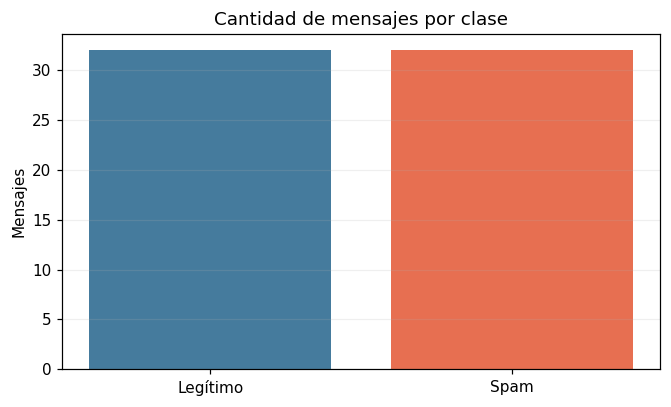

In [3]:
resumen_clases = (
    datos["clase"]
    .value_counts()
    .rename_axis("clase")
    .reset_index(name="mensajes")
)

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.bar(
    resumen_clases["clase"],
    resumen_clases["mensajes"],
    color=["#457B9D", "#E76F51"],
)
ax.set_title("Cantidad de mensajes por clase")
ax.set_ylabel("Mensajes")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

resumen_clases


El conjunto está equilibrado: contiene la misma cantidad de mensajes spam y legítimos. Esto facilita la demostración, pero no representa necesariamente la proporción de un correo real.

Además, una fila corresponde a un mensaje completo. Las palabras todavía no son columnas numéricas; esa transformación se realizará después de reservar el test.


## 3. Reservar el conjunto de prueba

Separaremos el 25% de los mensajes como test final. Todo lo que implique comparar representaciones, variantes o valores de `alpha` se hará solamente con el conjunto de desarrollo.

La estratificación conserva la proporción de ambas clases.


In [4]:
(
    X_desarrollo,
    X_test_final,
    y_desarrollo,
    y_test_final,
) = train_test_split(
    datos["mensaje"],
    datos["spam"],
    test_size=0.25,
    random_state=24,
    stratify=datos["spam"],
)

pd.DataFrame({
    "conjunto": ["Desarrollo", "Test final"],
    "mensajes": [len(X_desarrollo), len(X_test_final)],
    "spam": [y_desarrollo.sum(), y_test_final.sum()],
    "legitimos": [
        (y_desarrollo == 0).sum(),
        (y_test_final == 0).sum(),
    ],
})


,conjunto,mensajes,spam,legitimos
0,Desarrollo,48,24,24
1,Test final,16,8,8


## 4. Convertir palabras en conteos

`CountVectorizer` crea un vocabulario a partir de los textos y transforma cada mensaje en una fila de conteos:

- cada columna representa un término;
- `0` indica que el término no aparece;
- un valor mayor indica cuántas veces aparece.

Ajustaremos ahora un vectorizador sobre desarrollo para inspeccionar la representación. Más adelante, durante la validación cruzada, esta transformación quedará dentro del pipeline para que el vocabulario se aprenda de nuevo en cada fold.


In [5]:
vectorizador_demo = CountVectorizer(
    lowercase=True,
    strip_accents="unicode",
)
X_conteos = vectorizador_demo.fit_transform(X_desarrollo)
vocabulario = vectorizador_demo.get_feature_names_out()

pd.DataFrame({
    "mensajes_desarrollo": [X_conteos.shape[0]],
    "terminos_vocabulario": [X_conteos.shape[1]],
    "celdas_posibles": [X_conteos.shape[0] * X_conteos.shape[1]],
    "conteos_no_nulos": [X_conteos.nnz],
    "porcentaje_ceros": [
        100 * (1 - X_conteos.nnz / (X_conteos.shape[0] * X_conteos.shape[1]))
    ],
}).round(2)


,mensajes_desarrollo,terminos_vocabulario,celdas_posibles,conteos_no_nulos,porcentaje_ceros
0,48,229,10992,419,96.19


In [6]:
terminos_muestra = [
    termino
    for termino in [
        "gratis",
        "premio",
        "reunion",
        "factura",
        "enlace",
        "biblioteca",
    ]
    if termino in vectorizador_demo.vocabulary_
]

columnas_muestra = [
    vectorizador_demo.vocabulary_[termino]
    for termino in terminos_muestra
]

tabla_conteos = pd.DataFrame(
    X_conteos[:10, columnas_muestra].toarray(),
    columns=terminos_muestra,
)
tabla_conteos.insert(
    0,
    "mensaje",
    X_desarrollo.iloc[:10].str.slice(0, 58).to_numpy(),
)
tabla_conteos.insert(
    1,
    "clase",
    y_desarrollo.iloc[:10].map({0: "Legítimo", 1: "Spam"}).to_numpy(),
)
tabla_conteos


,mensaje,clase,gratis,premio,reunion,factura,enlace,biblioteca
0,"Ganaste entradas gratis, verificá tu identidad para recibi",Spam,1,0,0,0,0,0
1,"Oferta exclusiva: ganaste un premio, hacé clic para reclam",Spam,0,1,0,0,0,0
2,"Banco: detectamos un problema, confirmá tus datos de acces",Spam,0,0,0,0,0,0
3,Recordá llevar el documento para completar el trámite pres,Legítimo,0,0,0,0,0,0
4,Mensaje del soporte: necesitamos tu contraseña para ayudar,Spam,0,0,0,0,0,0
5,Confirmamos tu turno médico para el lunes a las nueve,Legítimo,0,0,0,0,0,0
6,La entrada al concierto incluye un cupón de descuento,Legítimo,0,0,0,0,0,0
7,"Tu correo superó el límite, iniciá sesión desde este enlac",Spam,0,0,0,0,1,0
8,"Último aviso: tu cuenta será cerrada, verificá ahora tu co",Spam,0,0,0,0,0,0
9,"Trabajo desde casa con ganancias rápidas, registrate ahora",Spam,0,0,0,0,0,0


La matriz es dispersa: la mayoría de las celdas vale cero porque cada mensaje usa solo una pequeña parte del vocabulario. Esta estructura es habitual en texto.

También vemos que ninguna palabra determina por sí sola la clase. “Factura”, “gratis” y “enlace”, por ejemplo, aparecen en contextos distintos.


## 5. Aprender probabilidades por clase

`MultinomialNB` es adecuado para conteos no negativos. Durante el entrenamiento estima:

1. la frecuencia previa de cada clase;
2. la frecuencia de cada término dentro de cada clase;
3. una combinación probabilística de esas evidencias.

El modelo trata los términos como si aportaran información independiente una vez conocida la clase. Ese es el supuesto “naive”.


In [7]:
nb_demo = MultinomialNB(alpha=1.0)
nb_demo.fit(X_conteos, y_desarrollo)

pd.DataFrame({
    "clase": ["Legítimo", "Spam"],
    "mensajes_entrenamiento": nb_demo.class_count_,
    "probabilidad_previa": np.exp(nb_demo.class_log_prior_),
}).round(4)


,clase,mensajes_entrenamiento,probabilidad_previa
0,Legítimo,24.0,0.5
1,Spam,24.0,0.5


In [8]:
probabilidades_terminos = pd.DataFrame({
    "termino": vocabulario,
    "P(termino | legitimo)": np.exp(nb_demo.feature_log_prob_[0]),
    "P(termino | spam)": np.exp(nb_demo.feature_log_prob_[1]),
})
probabilidades_terminos["evidencia_spam"] = (
    nb_demo.feature_log_prob_[1]
    - nb_demo.feature_log_prob_[0]
)

probabilidades_terminos.loc[
    probabilidades_terminos["termino"].isin(terminos_muestra)
].sort_values("evidencia_spam", ascending=False).round(5)


,termino,P(termino | legitimo),P(termino | spam),evidencia_spam
157,premio,0.00450,0.01134,0.92307
73,enlace,0.00676,0.01361,0.69993
103,gratis,0.00450,0.00907,0.69993
85,factura,0.00901,0.00454,-0.68637
186,reunion,0.00901,0.00454,-0.68637
18,biblioteca,0.00901,0.00227,-1.37951


Una diferencia positiva en `evidencia_spam` indica que el término es relativamente más frecuente dentro de spam; una diferencia negativa lo relaciona más con mensajes legítimos.

No se trata de una regla causal. El modelo solo resume asociaciones observadas en este conjunto de entrenamiento.


## 6. Reconstruir una predicción

Para cada clase, `MultinomialNB` suma:

- el logaritmo de la probabilidad previa de la clase;
- el conteo de cada palabra multiplicado por su log-probabilidad dentro de esa clase.

Trabajar con logaritmos convierte productos muy pequeños en sumas numéricamente estables. Reconstruiremos el cálculo para el mensaje “oferta gratis premio”.


In [9]:
mensaje_manual = ["oferta gratis premio"]
vector_manual = vectorizador_demo.transform(mensaje_manual)

puntajes_log = (
    nb_demo.class_log_prior_
    + vector_manual @ nb_demo.feature_log_prob_.T
)
puntajes_log = np.asarray(puntajes_log).ravel()

puntajes_estables = puntajes_log - puntajes_log.max()
probabilidades_manual = (
    np.exp(puntajes_estables)
    / np.exp(puntajes_estables).sum()
)
probabilidades_modelo = nb_demo.predict_proba(vector_manual)[0]

pd.DataFrame({
    "clase": ["Legítimo", "Spam"],
    "puntaje_log_manual": puntajes_log,
    "probabilidad_manual": probabilidades_manual,
    "predict_proba": probabilidades_modelo,
}).round(8)


,clase,puntaje_log_manual,probabilidad_manual,predict_proba
0,Legítimo,-16.901179,0.072691,0.072691
1,Spam,-14.355112,0.927309,0.927309


La reconstrucción manual coincide con `predict_proba`. Las tres palabras aportan evidencia en la misma dirección y el modelo elige spam.

Esta probabilidad está condicionada por la representación, los datos y el supuesto de independencia. No debe interpretarse automáticamente como una certeza bien calibrada sobre mensajes del mundo real.


## 7. Evitar probabilidades nulas mediante suavizado

Si un término no apareció en una clase, una estimación sin suavizado le asignaría probabilidad cero. Al multiplicar evidencias, ese cero podría anular todo el puntaje de la clase.

El parámetro `alpha` agrega una pequeña cantidad a los conteos. Compararemos cómo cambia la predicción de un mensaje ambiguo que combina “bitcoin”, muy asociado al spam en desarrollo, con “reunión”, más frecuente en mensajes legítimos.


In [10]:
mensaje_ambiguo = ["reunión sobre bitcoin"]
valores_alpha = [0.01, 0.1, 1.0, 10.0, 100.0]
filas_alpha = []

for alpha in valores_alpha:
    modelo_alpha = MultinomialNB(alpha=alpha)
    modelo_alpha.fit(X_conteos, y_desarrollo)
    prob_spam = modelo_alpha.predict_proba(
        vectorizador_demo.transform(mensaje_ambiguo)
    )[0, 1]
    filas_alpha.append({
        "alpha": alpha,
        "P_spam": prob_spam,
        "clase_predicha": "Spam" if prob_spam >= 0.5 else "Legítimo",
    })

tabla_alpha = pd.DataFrame(filas_alpha)
tabla_alpha.round(4)


,alpha,P_spam,clase_predicha
0,0.01,0.4105,Legítimo
1,0.10,0.4130,Legítimo
2,1.00,0.4336,Legítimo
3,10.00,0.4809,Legítimo
4,100.00,0.4977,Legítimo


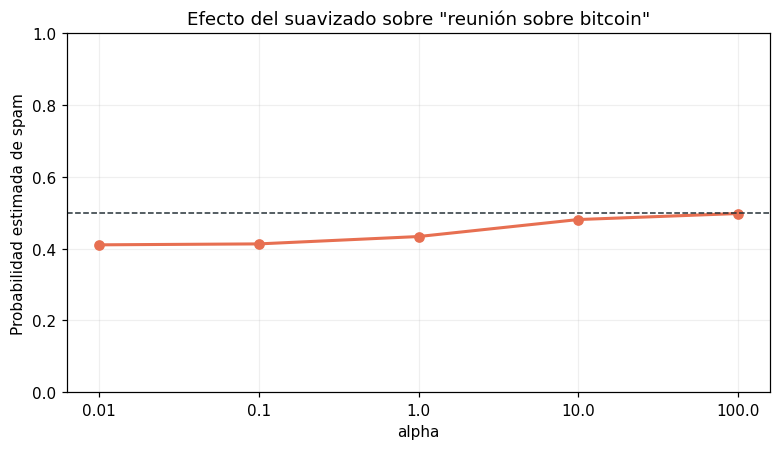

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(
    tabla_alpha["alpha"].astype(str),
    tabla_alpha["P_spam"],
    marker="o",
    color="#E76F51",
    linewidth=2,
)
ax.axhline(0.5, color="#263238", linestyle="--", linewidth=1)
ax.set_ylim(0, 1)
ax.set_xlabel("alpha")
ax.set_ylabel("Probabilidad estimada de spam")
ax.set_title('Efecto del suavizado sobre "reunión sobre bitcoin"')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


Con `alpha` pequeño, las diferencias observadas en el entrenamiento pesan más. Al aumentar `alpha`, las probabilidades de los términos se suavizan y la predicción se acerca a la distribución previa de las clases.

Un `alpha` grande no es automáticamente mejor: puede borrar señales útiles y producir subajuste. Debe elegirse con datos de validación.


## 8. Evaluar el flujo completo sin fuga

Durante la validación cruzada, el vocabulario no debe aprenderse con todos los mensajes antes de crear los folds. `CountVectorizer` y el clasificador formarán un único pipeline.

Compararemos cuatro referencias usando exactamente las mismas divisiones:

- clase previa con `DummyClassifier`;
- conteos con `MultinomialNB`;
- presencia o ausencia con `BernoulliNB`;
- conteos con regresión logística.


In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=24,
)

metricas_cv = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0,
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0,
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0,
    ),
}

modelos = {
    "Clase previa": Pipeline(steps=[
        ("vectorizador", CountVectorizer(strip_accents="unicode")),
        ("modelo", DummyClassifier(strategy="prior")),
    ]),
    "MultinomialNB": Pipeline(steps=[
        ("vectorizador", CountVectorizer(strip_accents="unicode")),
        ("modelo", MultinomialNB(alpha=1.0)),
    ]),
    "BernoulliNB": Pipeline(steps=[
        (
            "vectorizador",
            CountVectorizer(
                strip_accents="unicode",
                binary=True,
            ),
        ),
        ("modelo", BernoulliNB(alpha=1.0)),
    ]),
    "Regresión logística": Pipeline(steps=[
        ("vectorizador", CountVectorizer(strip_accents="unicode")),
        (
            "modelo",
            LogisticRegression(
                max_iter=2000,
                random_state=24,
            ),
        ),
    ]),
}

filas_modelos = []
for nombre, pipeline in modelos.items():
    resultados = cross_validate(
        pipeline,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring=metricas_cv,
    )
    filas_modelos.append({
        "modelo": nombre,
        "accuracy_media": resultados["test_accuracy"].mean(),
        "precision_media": resultados["test_precision"].mean(),
        "recall_medio": resultados["test_recall"].mean(),
        "F1_medio": resultados["test_f1"].mean(),
        "F1_desviacion": resultados["test_f1"].std(),
    })

comparacion_modelos = (
    pd.DataFrame(filas_modelos)
    .sort_values("F1_medio", ascending=False)
    .reset_index(drop=True)
)
comparacion_modelos.round(4)


,modelo,accuracy_media,precision_media,recall_medio,F1_medio,F1_desviacion
0,Regresión logística,0.9156,0.8933,0.96,0.9192,0.0414
1,MultinomialNB,0.8533,0.9167,0.79,0.8374,0.0717
2,BernoulliNB,0.8333,0.8929,0.79,0.8222,0.0624
3,Clase previa,0.4778,0.0889,0.20,0.1231,0.2462


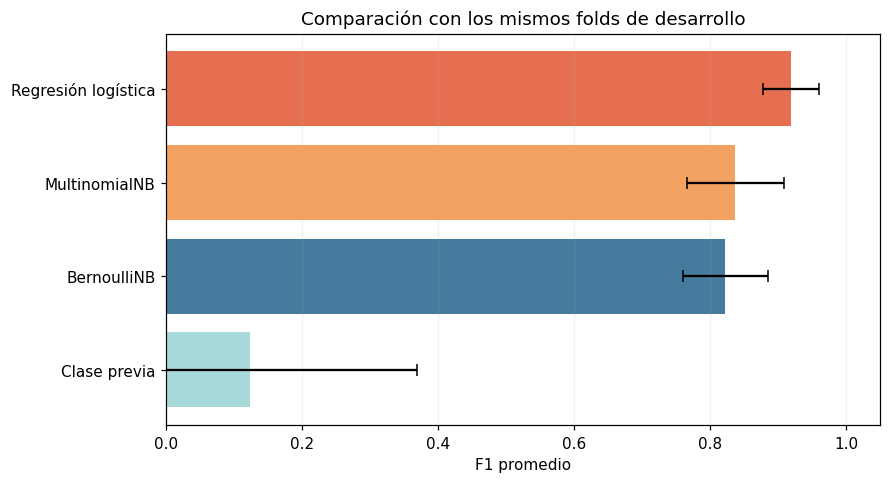

In [13]:
fig, ax = plt.subplots(figsize=(8.2, 4.5))
orden = comparacion_modelos.sort_values("F1_medio")
ax.barh(
    orden["modelo"],
    orden["F1_medio"],
    xerr=orden["F1_desviacion"],
    color=["#A8DADC", "#457B9D", "#F4A261", "#E76F51"],
    capsize=4,
)
ax.set_xlim(0, 1.05)
ax.set_xlabel("F1 promedio")
ax.set_title("Comparación con los mismos folds de desarrollo")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


Los modelos que usan el contenido superan claramente a la referencia basada solo en la proporción de clases. Esto indica que el texto contiene señal útil. La regresión logística obtiene F1 promedio `0,919`; `MultinomialNB`, `0,837`; y `BernoulliNB`, `0,822`.

Las diferencias entre modelos deben leerse con prudencia: el conjunto es pequeño, artificial y las barras de error reflejan variación entre apenas cinco folds. La comparación muestra un procedimiento, no una conclusión general sobre cuál algoritmo es siempre mejor.


## 9. Elegir representación y suavizado en desarrollo

Buscaremos una configuración para `MultinomialNB` sin consultar el test final. Compararemos:

- unigramas: palabras aisladas;
- unigramas y bigramas: también pares consecutivos;
- conteos y TF-IDF;
- distintos valores de `alpha`.

`MultinomialNB` admite características no negativas, por lo que puede trabajar tanto con conteos como con valores TF-IDF.


In [14]:
pipeline_nb = Pipeline(steps=[
    (
        "vectorizador",
        CountVectorizer(strip_accents="unicode"),
    ),
    ("modelo", MultinomialNB()),
])

grilla_parametros = [
    {
        "vectorizador": [
            CountVectorizer(strip_accents="unicode"),
        ],
        "vectorizador__ngram_range": [(1, 1), (1, 2)],
        "modelo__alpha": [0.1, 0.5, 1.0, 2.0, 5.0],
    },
    {
        "vectorizador": [
            TfidfVectorizer(strip_accents="unicode"),
        ],
        "vectorizador__ngram_range": [(1, 1), (1, 2)],
        "modelo__alpha": [0.1, 0.5, 1.0, 2.0, 5.0],
    },
]

busqueda = GridSearchCV(
    estimator=pipeline_nb,
    param_grid=grilla_parametros,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
busqueda.fit(X_desarrollo, y_desarrollo)

{
    "mejores_parametros": busqueda.best_params_,
    "mejor_F1_validacion": round(busqueda.best_score_, 4),
    "configuraciones": len(busqueda.cv_results_["params"]),
}


{'mejores_parametros': {'modelo__alpha': 0.5, 'vectorizador': CountVectorizer(strip_accents='unicode'), 'vectorizador__ngram_range': (1, 2)}, 'mejor_F1_validacion': np.float64(0.8707), 'configuraciones': 20}

In [15]:
resultados_busqueda = pd.DataFrame(busqueda.cv_results_)
resultados_busqueda["representacion"] = resultados_busqueda[
    "param_vectorizador"
].map(lambda x: type(x).__name__.replace("Vectorizer", ""))
resultados_busqueda["ngramas"] = resultados_busqueda[
    "param_vectorizador__ngram_range"
].astype(str)

columnas_resultados = [
    "representacion",
    "ngramas",
    "param_modelo__alpha",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]

resultados_busqueda[
    columnas_resultados
].sort_values(
    ["rank_test_score", "std_test_score"]
).head(10).round(4)


,representacion,ngramas,param_modelo__alpha,mean_train_score,mean_test_score,std_test_score,rank_test_score
3,Count,"(1, 2)",0.5,1.0,0.8707,0.1100,1
5,Count,"(1, 2)",1.0,1.0,0.8707,0.1100,1
11,Tfidf,"(1, 2)",0.1,1.0,0.8518,0.0905,3
2,Count,"(1, 1)",0.5,1.0,0.8374,0.0717,4
4,Count,"(1, 1)",1.0,1.0,0.8374,0.0717,4
1,Count,"(1, 2)",0.1,1.0,0.8352,0.1127,6
13,Tfidf,"(1, 2)",0.5,1.0,0.8352,0.1127,6
17,Tfidf,"(1, 2)",2.0,1.0,0.8352,0.1178,6
15,Tfidf,"(1, 2)",1.0,1.0,0.8307,0.0903,9
7,Count,"(1, 2)",2.0,1.0,0.8207,0.0957,10


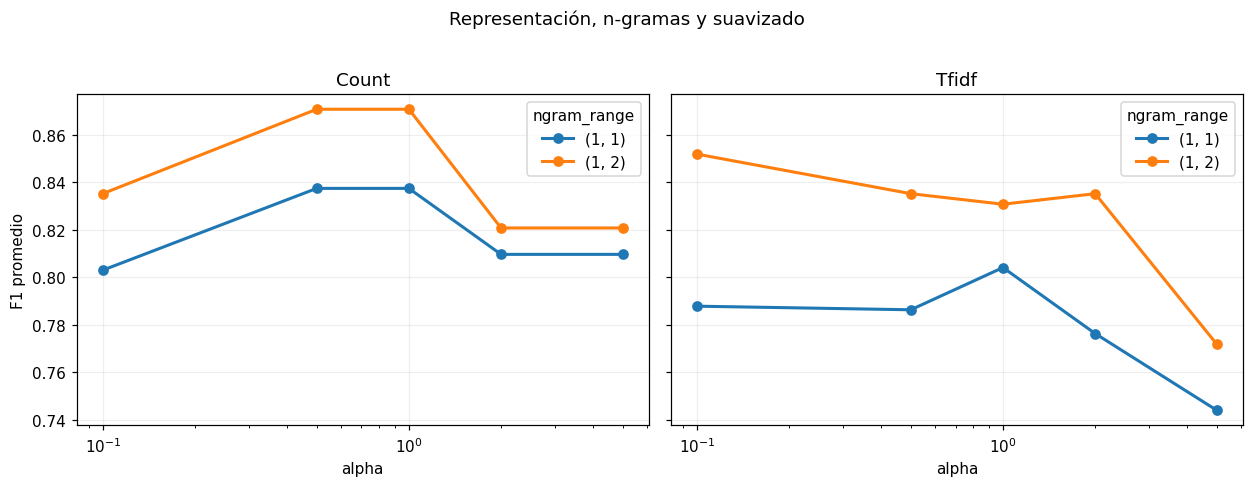

In [16]:
resumen_grilla = (
    resultados_busqueda
    .groupby(
        ["representacion", "ngramas", "param_modelo__alpha"],
        as_index=False,
    )["mean_test_score"]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True)
for ax, representacion in zip(axes, ["Count", "Tfidf"]):
    parte = resumen_grilla[
        resumen_grilla["representacion"] == representacion
    ]
    for ngramas, grupo in parte.groupby("ngramas"):
        ax.plot(
            grupo["param_modelo__alpha"].astype(float),
            grupo["mean_test_score"],
            marker="o",
            linewidth=2,
            label=ngramas,
        )
    ax.set_xscale("log")
    ax.set_xlabel("alpha")
    ax.set_title(representacion)
    ax.grid(alpha=0.2)
    ax.legend(title="ngram_range")

axes[0].set_ylabel("F1 promedio")
fig.suptitle("Representación, n-gramas y suavizado", y=1.02)
plt.tight_layout()
plt.show()


La grilla no pregunta solamente “qué modelo usar”. También compara cómo representar el texto. En problemas de lenguaje, esa decisión puede ser tan importante como el clasificador.

La mejor media es `0,8707` y aparece empatada para dos valores de suavizado: conteos con unigramas y bigramas obtiene el mismo resultado con `alpha=0,5` y `alpha=1,0`. `GridSearchCV` devuelve la primera configuración empatada según el orden de la grilla; no existe evidencia para declarar que `0,5` sea intrínsecamente superior.

Si varias configuraciones quedan casi empatadas, no corresponde atribuir significado fuerte a diferencias mínimas. Un conjunto mayor y más representativo permitiría decidir con más confianza.


## 10. Evaluar una sola vez sobre el test final

`GridSearchCV` ya volvió a ajustar la mejor configuración con todos los datos de desarrollo. Ahora consultaremos el test reservado una única vez.

Además de F1 y accuracy, revisaremos precision, recall y la matriz de confusión. En un filtro real, enviar un correo legítimo a spam y dejar pasar un mensaje peligroso tienen costos diferentes.


In [17]:
mejor_modelo = busqueda.best_estimator_
pred_test = mejor_modelo.predict(X_test_final)

metricas_test = pd.DataFrame({
    "metrica": ["Accuracy", "Precision", "Recall", "F1"],
    "valor": [
        accuracy_score(y_test_final, pred_test),
        precision_score(y_test_final, pred_test),
        recall_score(y_test_final, pred_test),
        f1_score(y_test_final, pred_test),
    ],
})
metricas_test.round(4)


,metrica,valor
0,Accuracy,0.7500
1,Precision,1.0000
2,Recall,0.5000
3,F1,0.6667


array([[8, 0],
       [4, 4]])

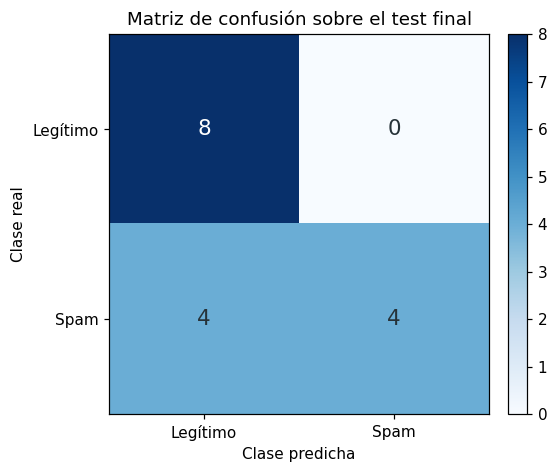

In [18]:
matriz = confusion_matrix(y_test_final, pred_test)

fig, ax = plt.subplots(figsize=(5.3, 4.4))
imagen = ax.imshow(matriz, cmap="Blues")
for fila in range(2):
    for columna in range(2):
        valor = matriz[fila, columna]
        color = "white" if valor > matriz.max() / 2 else "#263238"
        ax.text(
            columna,
            fila,
            valor,
            ha="center",
            va="center",
            fontsize=14,
            color=color,
        )
ax.set_xticks([0, 1], ["Legítimo", "Spam"])
ax.set_yticks([0, 1], ["Legítimo", "Spam"])
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.set_title("Matriz de confusión sobre el test final")
fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

matriz


In [19]:
revision_test = pd.DataFrame({
    "mensaje": X_test_final.to_numpy(),
    "clase_real": y_test_final.map({0: "Legítimo", 1: "Spam"}).to_numpy(),
    "clase_predicha": pd.Series(pred_test).map(
        {0: "Legítimo", 1: "Spam"}
    ),
    "P_spam": mejor_modelo.predict_proba(X_test_final)[:, 1],
})
revision_test["correcto"] = (
    revision_test["clase_real"] == revision_test["clase_predicha"]
)

revision_test.sort_values(
    ["correcto", "P_spam"],
    ascending=[True, False],
).round({"P_spam": 4})


,mensaje,clase_real,clase_predicha,P_spam,correcto
11,Promoción urgente: descuento total solo por hoy,Spam,Legítimo,0.3832,False
2,Alerta de seguridad: enviá tu clave para evitar el bloqueo,Spam,Legítimo,0.3031,False
13,Aviso de cobro: descargá la factura desde este enlace desconocido,Spam,Legítimo,0.1857,False
6,Factura pendiente: abrí el archivo y confirmá el pago urgente,Spam,Legítimo,0.1544,False
0,Promoción especial para clientes: reclamá tu regalo ahora,Spam,Spam,0.9805,True
8,"Tu paquete está retenido, pagá la tasa desde este enlace",Spam,Spam,0.9630,True
15,"Cupón gratis disponible, hacé clic antes de que venza",Spam,Spam,0.9529,True
10,Descuento exclusivo: comprá ahora y recibí otro producto gratis,Spam,Spam,0.7997,True
7,El club ofrece una promoción para socios durante julio,Legítimo,Legítimo,0.1230,True
4,El museo tendrá entrada gratis durante el fin de semana,Legítimo,Legítimo,0.0705,True


En el test final, el modelo acierta los ocho mensajes legítimos y cuatro de los ocho mensajes spam. Por eso obtiene precision `1,000`, recall `0,500`, F1 `0,667` y accuracy `0,750`. La ausencia de falsas alarmas no compensa automáticamente los cuatro mensajes sospechosos que dejó pasar: el costo relativo depende del objetivo del sistema.

La tabla permite mirar más allá del promedio. Los errores se concentran en mensajes donde vocabulario legítimo y sospechoso se mezclan o donde las señales decisivas no quedaron bien representadas en desarrollo.

Las probabilidades sirven para ordenar casos y aplicar umbrales, pero este pequeño test no alcanza para afirmar que estén bien calibradas. Una aplicación real necesitaría muchos más mensajes, procedentes del contexto donde se usará el sistema.


## 11. Examinar qué términos aportan evidencia

Inspeccionaremos las diferencias entre las log-probabilidades aprendidas. Los términos del extremo positivo aportan más evidencia relativa a spam; los del extremo negativo, a mensajes legítimos.

Si la configuración elegida usa bigramas, también pueden aparecer pares de palabras.


,termino,evidencia_spam,grupo
134,de la,-2.188548,Legítimo
302,la,-2.143085,Legítimo
37,biblioteca,-1.937233,Legítimo
243,fue,-1.937233,Legítimo
304,la biblioteca,-1.937233,Legítimo
311,la factura,-1.937233,Legítimo
400,podes,-1.937233,Legítimo
61,clase,-1.600761,Legítimo
177,el documento,-1.600761,Legítimo
184,el portal,-1.600761,Legítimo


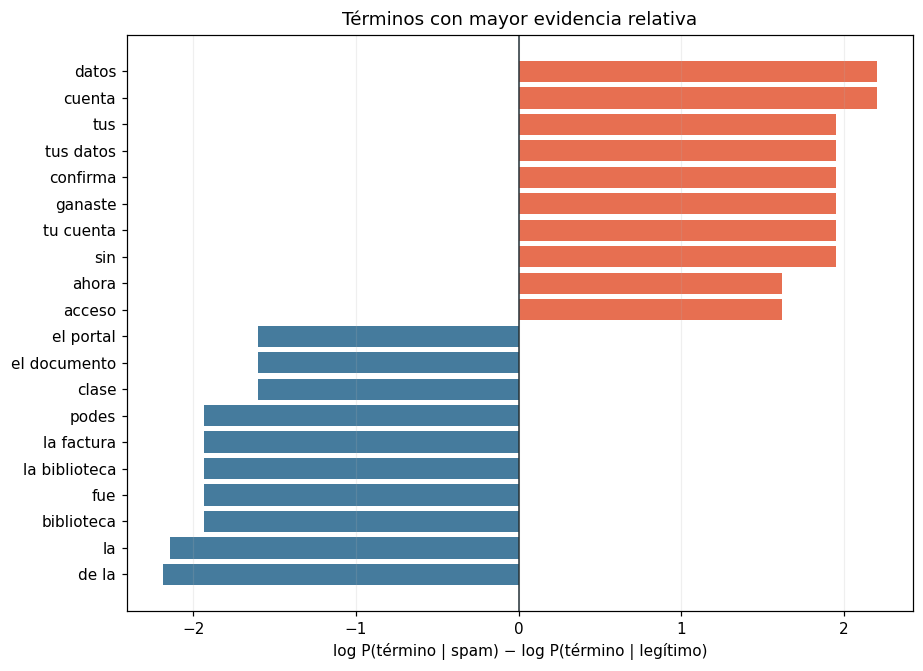

In [20]:
vectorizador_final = mejor_modelo.named_steps["vectorizador"]
nb_final = mejor_modelo.named_steps["modelo"]
terminos_finales = vectorizador_final.get_feature_names_out()

evidencia = (
    nb_final.feature_log_prob_[1]
    - nb_final.feature_log_prob_[0]
)
ranking = pd.DataFrame({
    "termino": terminos_finales,
    "evidencia_spam": evidencia,
})

extremos = pd.concat([
    ranking.nsmallest(10, "evidencia_spam").assign(grupo="Legítimo"),
    ranking.nlargest(10, "evidencia_spam").assign(grupo="Spam"),
]).sort_values("evidencia_spam")

fig, ax = plt.subplots(figsize=(8.5, 6.2))
colores = extremos["grupo"].map(
    {"Legítimo": "#457B9D", "Spam": "#E76F51"}
)
ax.barh(
    extremos["termino"],
    extremos["evidencia_spam"],
    color=colores,
)
ax.axvline(0, color="#263238", linewidth=1)
ax.set_xlabel("log P(término | spam) − log P(término | legítimo)")
ax.set_title("Términos con mayor evidencia relativa")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

extremos


Esta inspección ayuda a explicar el modelo, pero debe leerse como una asociación dentro de esta muestra. Incluso expresiones comunes como “la” o “de la” aparecen entre las evidencias porque, por casualidad, quedaron distribuidas de manera desigual en este pequeño conjunto. Eso no las convierte en señales generales de legitimidad. Un término puede cambiar de significado según el contexto, el idioma o el tipo de mensajes.

El supuesto de independencia también puede volver al modelo demasiado confiado cuando varias palabras relacionadas expresan casi la misma señal.


In [21]:
mensajes_nuevos = pd.Series([
    "oferta gratis premio urgente",
    "reunión gratuita en la biblioteca",
    "factura disponible en el portal",
    "factura urgente: confirmá tu contraseña en este enlace",
    "no ganaste ningún premio",
    "promoción para socios del club",
])

probabilidades_nuevas = mejor_modelo.predict_proba(mensajes_nuevos)[:, 1]

pd.DataFrame({
    "mensaje": mensajes_nuevos,
    "P_spam": probabilidades_nuevas,
    "clase_predicha": np.where(
        probabilidades_nuevas >= 0.5,
        "Spam",
        "Legítimo",
    ),
}).round({"P_spam": 4})


,mensaje,P_spam,clase_predicha
0,oferta gratis premio urgente,0.9557,Spam
1,reunión gratuita en la biblioteca,0.0001,Legítimo
2,factura disponible en el portal,0.0011,Legítimo
3,factura urgente: confirmá tu contraseña en este enlace,0.9996,Spam
4,no ganaste ningún premio,0.9553,Spam
5,promoción para socios del club,0.6838,Spam


El ejemplo “no ganaste ningún premio” deja visible una limitación de la bolsa de palabras: el término “premio” puede aportar evidencia de spam aunque la negación cambie el sentido. Los bigramas pueden recuperar parte del contexto, pero no resuelven toda la comprensión del lenguaje.


## 12. Elegir la variante según los datos

Naive Bayes es una familia de modelos:

| Variante | Representación típica | Ejemplo |
|---|---|---|
| `MultinomialNB` | conteos o frecuencias no negativas | cantidad de apariciones de palabras |
| `BernoulliNB` | variables binarias | presencia o ausencia de términos |
| `GaussianNB` | variables numéricas continuas | medidas físicas o biológicas |

No alcanza con elegir cualquier variante porque comparten el apellido “Naive Bayes”. Cada una representa las variables de una manera diferente.


In [22]:
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

cv_iris = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=24,
)
resultado_gaussiano = cross_validate(
    GaussianNB(),
    X_iris,
    y_iris,
    cv=cv_iris,
    scoring="accuracy",
)

pd.DataFrame({
    "modelo": ["GaussianNB"],
    "tipo_variables": ["Numéricas continuas"],
    "accuracy_media": [resultado_gaussiano["test_score"].mean()],
    "desviacion": [resultado_gaussiano["test_score"].std()],
}).round(4)


,modelo,tipo_variables,accuracy_media,desviacion
0,GaussianNB,Numéricas continuas,0.9533,0.04


Iris contiene medidas continuas de sépalos y pétalos. `GaussianNB` modela, para cada clase, la distribución de cada variable mediante una forma normal aproximada.

Este ejemplo solo muestra la correspondencia entre variante y tipo de dato. No convierte a GaussianNB en la mejor opción universal para variables continuas.


## 13. Actividad breve

Probá tus propios mensajes sin modificar el test reservado. Podés cambiar el contenido de `mensajes_prueba` y observar:

- qué clase predice el modelo;
- qué probabilidad asigna a spam;
- qué palabras parecen orientar la decisión;
- qué ocurre cuando agregás una negación o combinás vocabulario de ambas clases.


In [23]:
mensajes_prueba = pd.Series([
    "Escribí aquí un mensaje nuevo",
    "Oferta para la reunión del viernes",
])

prob_prueba = mejor_modelo.predict_proba(mensajes_prueba)[:, 1]

pd.DataFrame({
    "mensaje": mensajes_prueba,
    "P_spam": prob_prueba,
    "prediccion": np.where(prob_prueba >= 0.5, "Spam", "Legítimo"),
}).round({"P_spam": 4})


,mensaje,P_spam,prediccion
0,Escribí aquí un mensaje nuevo,0.8674,Spam
1,Oferta para la reunión del viernes,0.0216,Legítimo


## 14. Ventajas y limitaciones

Naive Bayes ofrece varias ventajas:

- entrena y predice con rapidez;
- funciona bien con matrices de texto muy dispersas;
- combina muchas señales pequeñas;
- resulta relativamente sencillo de explicar;
- constituye una referencia útil frente a modelos más complejos.

Sus principales limitaciones son:

- supone independencia condicional entre variables;
- puede perder orden, contexto, negaciones e interacciones;
- depende mucho de la representación elegida;
- puede producir probabilidades demasiado extremas;
- los términos raros requieren suavizado;
- una variante inadecuada puede representar mal los datos.

Un modelo simple no elimina las reglas metodológicas: el preprocesamiento debe permanecer dentro del pipeline, la métrica debe responder al objetivo y el test final no debe intervenir en la selección.


## 15. Síntesis

En este cuaderno:

- convertimos mensajes en conteos de palabras;
- observamos una matriz dispersa;
- interpretamos probabilidades previas y condicionales;
- reconstruimos una predicción de `MultinomialNB`;
- estudiamos el efecto del suavizado `alpha`;
- comparamos conteos, presencia binaria y regresión logística;
- evaluamos el pipeline completo mediante validación cruzada;
- elegimos representación, n-gramas y suavizado dentro de desarrollo;
- consultamos el test final una única vez;
- inspeccionamos términos asociados a cada clase;
- reconocimos límites relacionados con contexto y calibración;
- distinguimos las variantes Multinomial, Bernoulli y Gaussiana.

Naive Bayes transforma frecuencias en evidencias probabilísticas. Su simplificación central lo vuelve rápido y claro, pero también exige prudencia: clasificar bien no significa representar todas las relaciones del lenguaje ni producir probabilidades perfectamente confiables.


## Para pensar

1. ¿Por qué el vocabulario debe aprenderse dentro de cada fold de validación?
2. ¿Qué problema evita el suavizado cuando una palabra no apareció en una clase?
3. ¿En qué situación elegirías `BernoulliNB` en lugar de `MultinomialNB`?
4. ¿Por qué varias palabras relacionadas pueden volver demasiado extrema una probabilidad?
5. ¿Qué evidencia necesitarías antes de usar este modelo como filtro de correo real?


---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
